Objetivo

Tu tarea consiste en desarrollar un modelo predictivo para una tienda minorista que desea pronosticar las ventas basándose en diversas características.

La tienda ha estado recopilando datos sobre las ventas diarias y quiere utilizar esta información para tomar decisiones informadas sobre la gestión de inventario, promociones y programación de personal.

Tu objetivo es construir un modelo que pueda predecir el total de ventas para el próximo mes utilizando datos de los meses anteriores.

Tarea
1. Preparación de Datos
Carga el conjunto de datos y realiza cualquier preprocesamiento necesario, como manejar valores faltantes, selección de variables dependientes e independientes y dividir los datos en conjuntos de entrenamiento y prueba.

2. Análisis Exploratorio de Datos (EDA)
Realiza un EDA para entender la distribución de las ventas y la relación entre las ventas y otras características. Esto podría incluir trazar las ventas a lo largo del tiempo, analizar las ventas en festivos vs. no festivos y el impacto de las promociones.

3. Selección de Modelo
Utiliza el conocimiento que has adquirido sobre diferentes algoritmos para elegir el modelo más adecuado para esta tarea. Considera la Regresión Lineal, los Árboles de Decisión y los Bosques Aleatorios.

4. Entrenamiento y Evaluación del Modelo
Entrena tu modelo seleccionado en el conjunto de entrenamiento y evalúa su rendimiento utilizando el conjunto de prueba. Utiliza gráficos para visualizar las ventas reales vs. las predichas.

5. Conclusión
Basado en los resultados iniciales, resume tus hallazgos y realiza recomendaciones para la tienda minorista sobre cómo utilizar el análisis predictivo para una mejor toma de decisiones.

Nota

Enfócate en la claridad y simplicidad de tu código.

¡Mucha Suerte!

In [2]:
# Importamos paqueterias

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [3]:
# Primero va vamos a importar los datos

df = pd.read_csv(r"C:\Users\emman\OneDrive\Jupyter_projects\Python para data science y Machine Learning\Dia 11\Ventas.csv")
df

,Fecha,DíaDeLaSemana,Promociones,Festivo,Ventas
0,2022-01-01,6,0,0,4033
1,2022-01-02,7,0,1,4012
2,2022-01-03,1,0,0,1608
3,2022-01-04,2,1,0,2046
4,2022-01-05,3,0,0,2484
...,...,...,...,...,...
360,2022-12-27,2,1,0,2189
361,2022-12-28,3,0,0,2548
362,2022-12-29,4,0,0,3018
363,2022-12-30,5,0,0,3591


In [4]:
# Ahora vamos a analizar los datos y si es necesario vamos a hacer una limpieza de los datos

print(df.info())
print("\n---------------------------------------------------------------------------------------------\n")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Fecha          365 non-null    str  
 1   DíaDeLaSemana  365 non-null    int64
 2   Promociones    365 non-null    int64
 3   Festivo        365 non-null    int64
 4   Ventas         365 non-null    int64
dtypes: int64(4), str(1)
memory usage: 14.4 KB
None

---------------------------------------------------------------------------------------------

Fecha            0
DíaDeLaSemana    0
Promociones      0
Festivo          0
Ventas           0
dtype: int64


In [5]:
# Como en el csv las fechas son de tipo string las vamos a cambiar a tipo fecha

df['Fecha'] = pd.to_datetime(df['Fecha'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Fecha          365 non-null    datetime64[us]
 1   DíaDeLaSemana  365 non-null    int64         
 2   Promociones    365 non-null    int64         
 3   Festivo        365 non-null    int64         
 4   Ventas         365 non-null    int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 14.4 KB


## 2. Análisis Exploratorio de Datos (EDA)

In [6]:
# Estadísticas descriptivas de las ventas

print("---------Analisis de las ventas------------------------")
print(df['Ventas'].describe())
print("---------Analisis de las promociones------------------------")
print(df['Promociones'].describe())
print("---------Analisis de los días (festivos o no)-----------------------")
print(df['Festivo'].describe())

---------Analisis de las ventas------------------------
count     365.000000
mean     2997.219178
std       942.096284
min      1305.000000
25%      2195.000000
50%      3074.000000
75%      3979.000000
max      4404.000000
Name: Ventas, dtype: float64
---------Analisis de las promociones------------------------
count    365.000000
mean       0.200000
std        0.400549
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: Promociones, dtype: float64
---------Analisis de los días (festivos o no)-----------------------
count    365.000000
mean       0.142466
std        0.350007
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: Festivo, dtype: float64


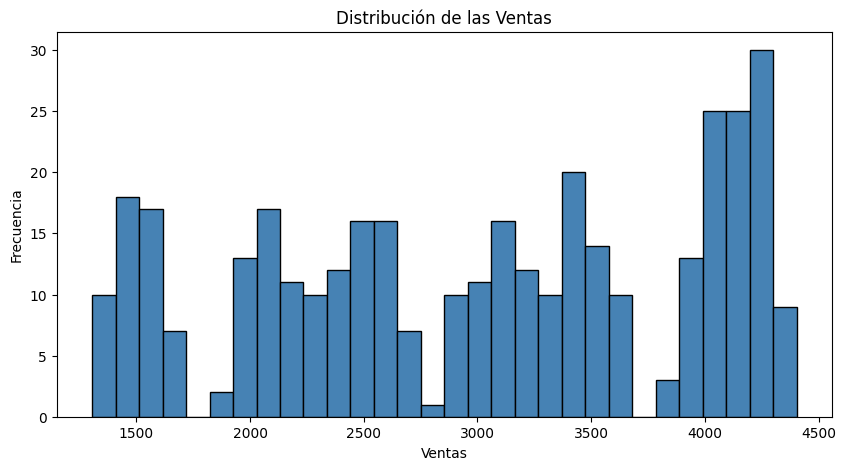

In [7]:
# Distribución de las ventas (histograma)
plt.figure(figsize=(10, 5))
plt.hist(df['Ventas'], bins=30, edgecolor='black', color='steelblue')
plt.title('Distribución de las Ventas')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.show()

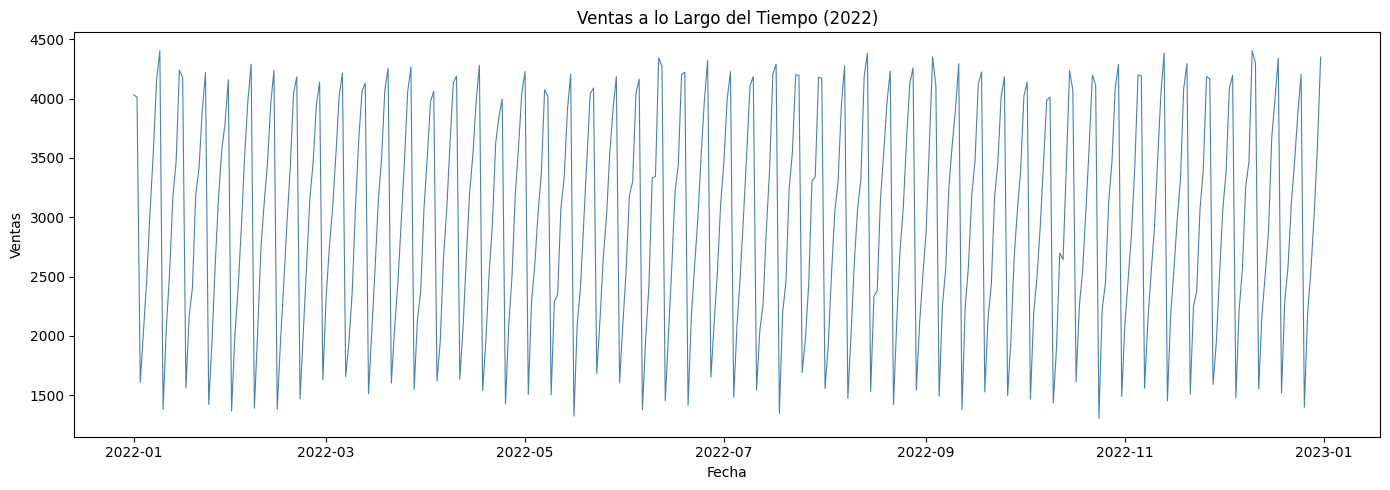

In [8]:
# Ventas a lo largo del tiempo
plt.figure(figsize=(14, 5))
plt.plot(df['Fecha'], df['Ventas'], color='steelblue', linewidth=0.8)
plt.title('Ventas a lo Largo del Tiempo (2022)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.tight_layout()
plt.show()

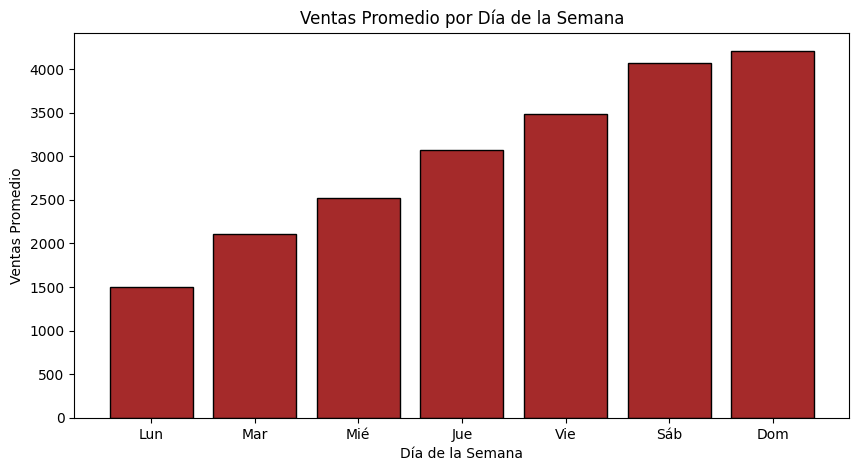

In [20]:
# Ventas por día de la semana
plt.figure(figsize=(10, 5))
ventas_por_dia = df.groupby('DíaDeLaSemana')['Ventas'].mean()
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
plt.bar(dias, ventas_por_dia.values, color='brown', edgecolor='black')
plt.title('Ventas Promedio por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Ventas Promedio')
plt.show()

C:\Users\emman\AppData\Local\Temp\ipykernel_24848\2160492815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='DíaDeLaSemana', y='Ventas', palette ='viridis')


Text(0, 0.5, 'Ventas promedio')

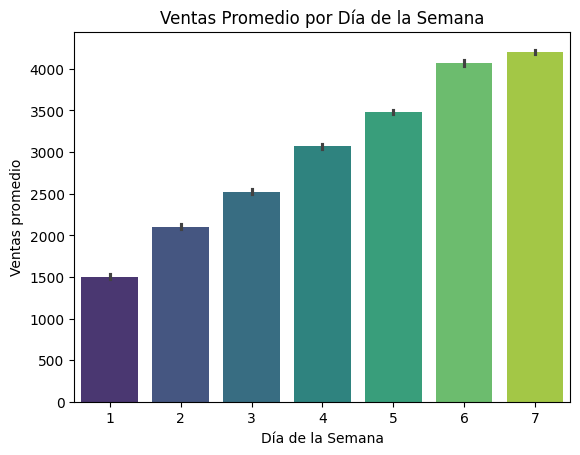

In [29]:
# Ahor vamos a ver con seaborn y ver si las ventas son consistentes

sns.barplot(data=df, x='DíaDeLaSemana', y='Ventas', palette ='viridis')
plt.title('Ventas Promedio por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Ventas promedio')

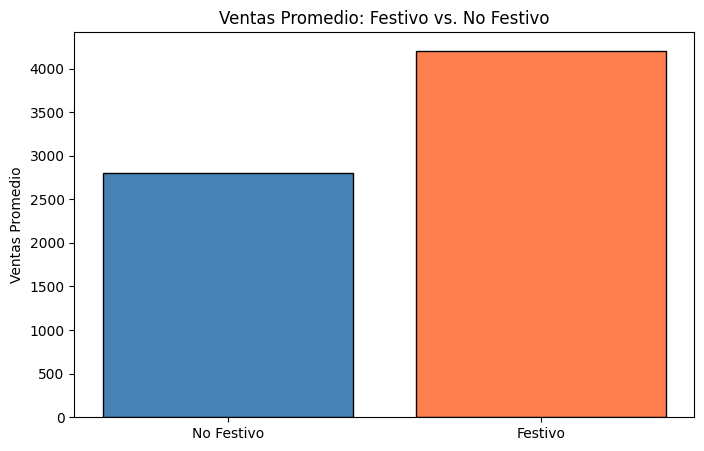

In [10]:
# Ventas en días festivos vs. no festivos
plt.figure(figsize=(8, 5))
ventas_festivo = df.groupby('Festivo')['Ventas'].mean()
plt.bar(['No Festivo', 'Festivo'], ventas_festivo.values, color=['steelblue', 'coral'], edgecolor='black')
plt.title('Ventas Promedio: Festivo vs. No Festivo')
plt.ylabel('Ventas Promedio')
plt.show()

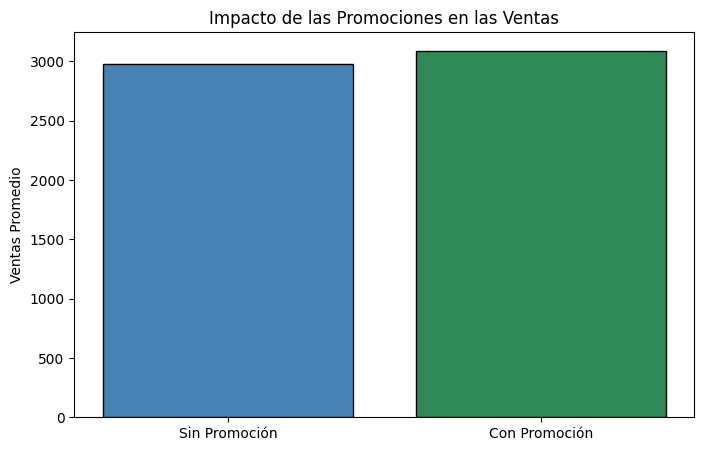

In [11]:
# Impacto de las promociones en las ventas
plt.figure(figsize=(8, 5))
ventas_promo = df.groupby('Promociones')['Ventas'].mean()
plt.bar(['Sin Promoción', 'Con Promoción'], ventas_promo.values, color=['steelblue', 'seagreen'], edgecolor='black')
plt.title('Impacto de las Promociones en las Ventas')
plt.ylabel('Ventas Promedio')
plt.show()

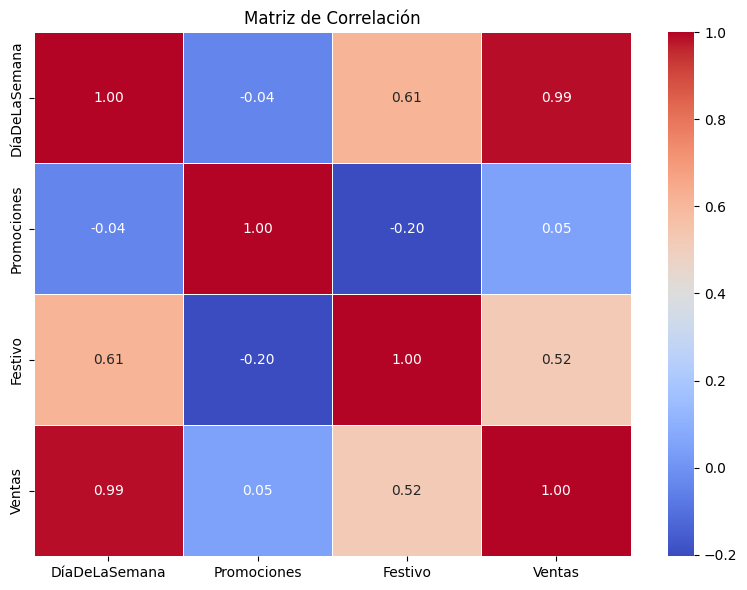

In [12]:
# Matriz de correlación
plt.figure(figsize=(8, 6))
correlacion = df[['DíaDeLaSemana', 'Promociones', 'Festivo', 'Ventas']].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

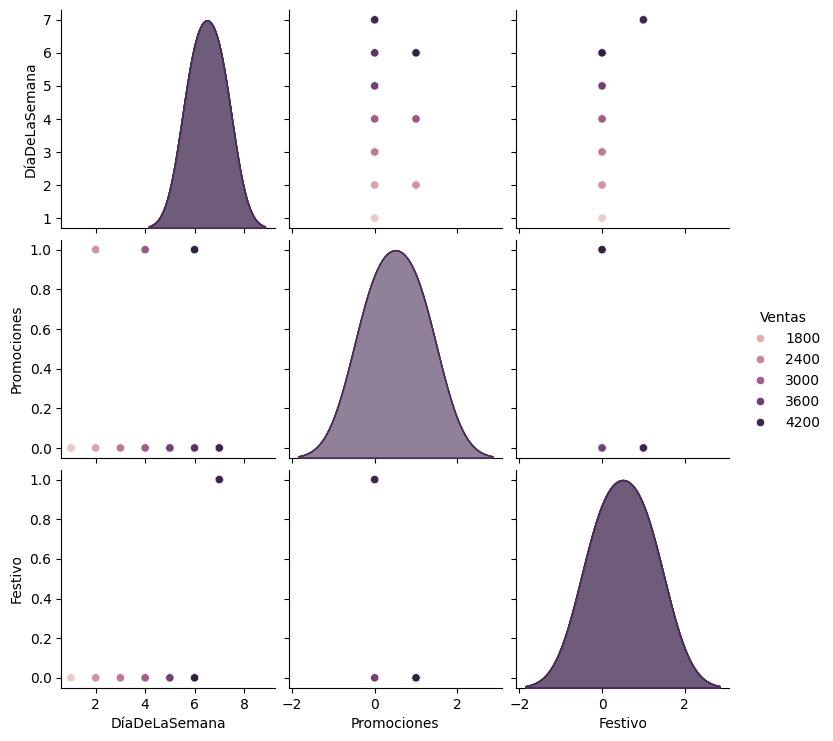

In [13]:
sns.pairplot(
    data= df,
    hue= 'Ventas'
);

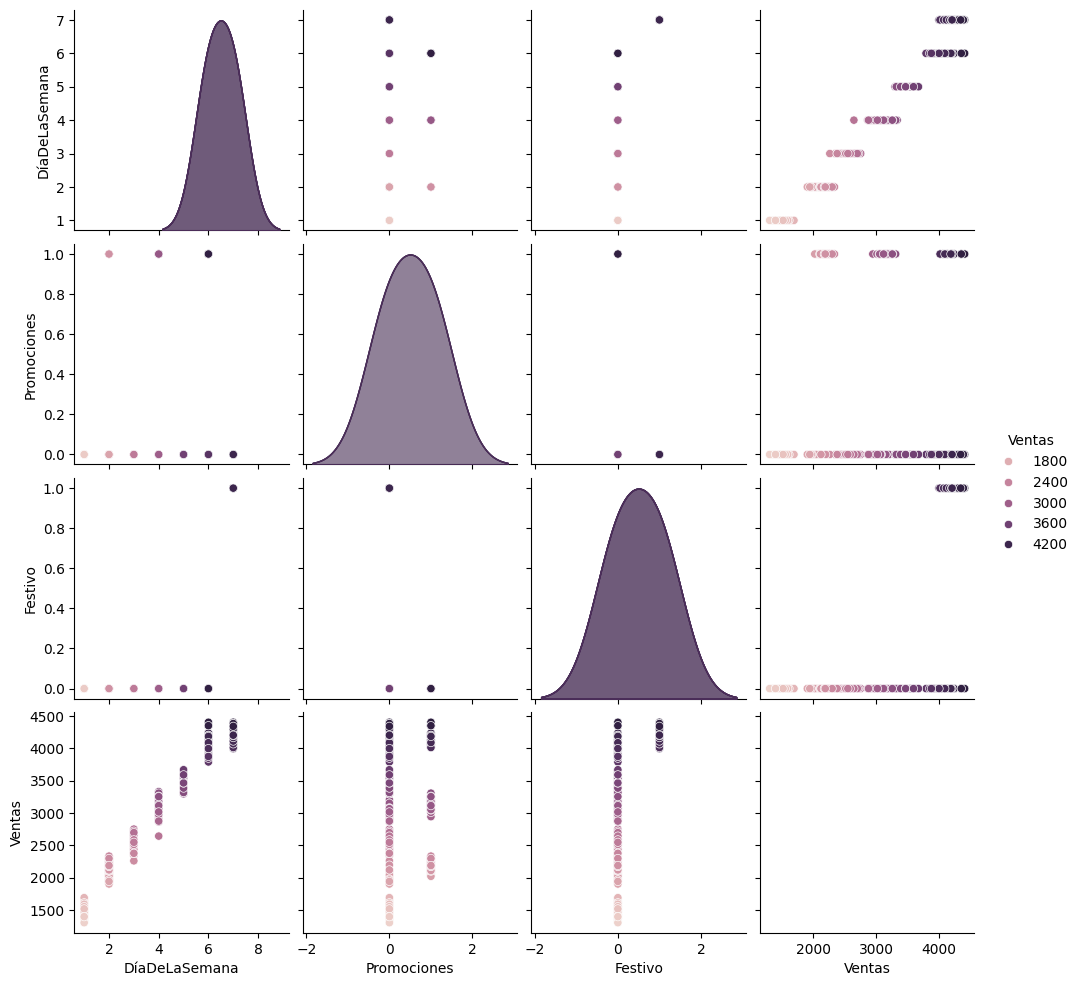

In [35]:
sns.pairplot(
    data= df,
    vars= ['DíaDeLaSemana', 'Promociones', 'Festivo', 'Ventas'],
    hue= 'Ventas',
);

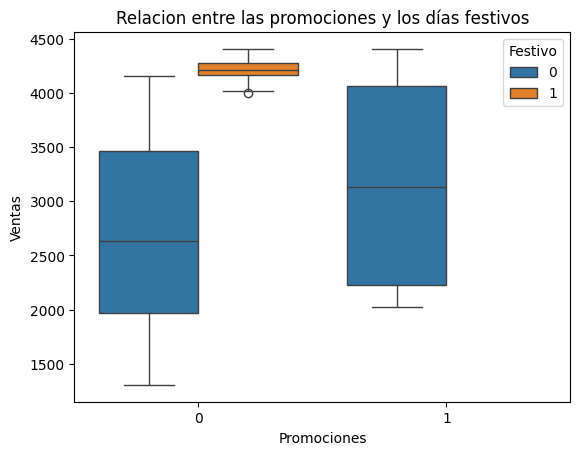

In [33]:
# Vamos a ver más a profundidad la interación entre promociones y dias festivos unicamente

sns.boxplot(data=df,x='Promociones',y='Ventas',hue='Festivo')
plt.title("Relacion entre las promociones y los días festivos");

In [15]:
# Ahora vamos a elegir el modelo más adecuado para esta tarea.
# Considerando la Regresión Lineal, los Árboles de Decisión y los Bosques Aleatorios.

from sklearn.model_selection import train_test_split

modelos = [
    ('regresion lineal', LinearRegression()),
    ('arboles de decision', DecisionTreeRegressor(random_state=42)),
    ('bosques aleatorios', RandomForestRegressor(n_estimators=50, random_state=42))
]

# X = características que el modelo usa para predecir
# y = lo que queremos predecir (Ventas)

X = df[['DíaDeLaSemana', 'Promociones', 'Festivo']]

y = df['Ventas']

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

for nombre, modelo in modelos:
    modelo.fit(X_entrena, y_entrena)
    puntaje = modelo.score(X_prueba, y_prueba)
    print(f"nombre: '{nombre}' y su puntaje es: {puntaje:.6f}")

nombre: 'regresion lineal' y su puntaje es: 0.992425
nombre: 'arboles de decision' y su puntaje es: 0.992351
nombre: 'bosques aleatorios' y su puntaje es: 0.992261


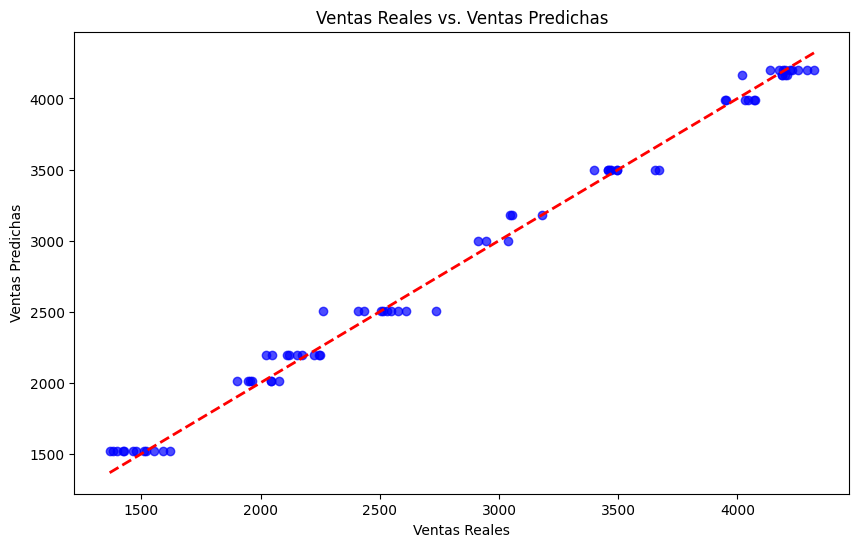

In [16]:
# Por lo que vamos a usar regresion lineal
# Seccion de: Entrenamiento y Evaluación del Modelo
# Vamos a entrenar el modelo seleccionado y evaluar su rendimiento
# Y al final visualizar las ventas reales vs. las predichas.

modelo_final = LinearRegression()
modelo_final.fit(X_entrena, y_entrena)

y_predicha = modelo_final.predict(X_prueba)


plt.figure(figsize=(10, 6))
plt.scatter(y_prueba, y_predicha, alpha=0.7, color='blue')
plt.plot([y_prueba.min(), y_prueba.max()], [y_prueba.min(), y_prueba.max()], 'r--', lw=2)
plt.xlabel('Ventas Reales')
plt.ylabel('Ventas Predichas')
plt.title('Ventas Reales vs. Ventas Predichas')
plt.show()


## 5. Conclusión

### Hallazgos principales

1. **El día de la semana es el predictor más fuerte de las ventas.** Las ventas siguen un patrón claro y consistente: son más bajas al inicio de la semana (lunes ~1,600) y aumentan progresivamente hacia el fin de semana (sábado/domingo ~4,000+). Este único factor explica la mayor parte de la variación en las ventas.

2. **Las promociones tienen un impacto bajo.** Aunque los días con promoción muestran ventas ligeramente diferentes, el efecto no es notorio comparado con el día de la semana. Solo el 20% de los días tuvieron promociones y la venta durante esas promociones practicamente fue igual.

3. **Los días festivos alteran las ventas.** En los días festivos las ventas aumentan, aunque pueda ser no tan significativo. Pues en los festivos (14.2% de los días) no muestran una diferencia notable en las ventas respecto a los días normales.

4. **Análisis de Promociones y días festivos.** Podemos ver que los días festivos no hay promociones, y las promociones nada más se hacen en martes, jueves y sabado. Además, los días festivos solo caen en domingo. Lo que confirma en análisis.

5. **Los tres modelos evaluados (Regresión Lineal, Árboles de Decisión y Bosques Aleatorios) obtuvieron un rendimiento casi idéntico (~99.2% R²).** Esto indica que la relación entre las variables y las ventas es fundamentalmente lineal y simple. No se necesitan modelos complejos para este caso.

6. **La Regresión Lineal es el modelo más adecuado** porque ofrece el mismo rendimiento o un poco superior que los modelos más complejos, pero es más fácil de interpretar y de implementar.
 

### Recomendaciones para la tienda

| Área | Recomendación |
|------|---------------|
| **Personal** | Programar más empleados los viernes, sábados y domingos, ya que son los días de mayor venta. O aumentar el tiempo que esta abierto a ventas. |
| **Inventario** | Abastecer más producto hacia finales de semana. Evitar sobre-stock los lunes y martes para reducir costos de almacenamiento. |
| **Promociones** | Reevaluar la estrategia actual de promociones, ya que no están generando un impacto en las ventas. Considerar enfocar promociones en días de baja venta (lunes-miércoles) para intentar aumentar las ventas en esos días o enfocar promociones de cantidad especiales los fines de semana. |
| **Análisis predictivo** | Si usamos el modelo de Regresión Lineal para pronosticar las ventas del próximo mes. Las predicciones serían muy cercanas a la realidad, lo que permitiría planificar inventario y personal con anticipación. |

### Limitaciones del análisis

- Solo se tienen 3 variables predictoras. En la realidad, factores como el clima, competencia, ubicación y temporadas del año pueden influir en las ventas.
- Este es un ejemplo de prueba: Un R² de 0.99 es inusualmente alto — en escenarios reales los modelos suelen tener menor precisión, y sería importante validar el modelo con datos nuevos antes de tomar decisiones críticas.